In [19]:
!pip -q install openpyxl mpltern
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from glob import glob
import mpltern

In [2]:
rsr_red = pd.read_excel("../data_in/L8_OLI_RSR.xlsx", sheet_name="Red")
rsr_nir = pd.read_excel("../data_in/L8_OLI_RSR.xlsx", sheet_name="NIR")

/srv/conda/envs/notebook/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/srv/conda/envs/notebook/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [3]:
def read_eco_spectrum(fname: str) -> pd.DataFrame:
    binomial = fname.split(".")[2] + " " + fname.split(".")[3]
    spectrum = pd.read_csv(
        fname,
        skiprows=21,
        sep="\t",
        header=None,
        names=["lambda_um", "reflectance"]
    )
    spectrum["src"] = fname
    return spectrum

In [4]:
from itertools import chain

nonsyn_patterns = [
    "nonphotosyntheticvegetation.needles*vswir*spectrum.txt",
    "nonphotosyntheticvegetation.leaves*vswir*spectrum.txt",
]

canopy_patterns = [
    "vegetation.tree*vswir*spectrum.txt"
]

soil_patterns = [
    "soil.aridisol*all*spectrum.txt",
    "soil.alfisol*all*spectrum.txt"
]

nonsyn = list(chain.from_iterable([glob("../data_in/ecospeclib/"+p) for p in nonsyn_patterns]))
canopy = list(chain.from_iterable([glob("../data_in/ecospeclib/"+p) for p in canopy_patterns]))
soil   = list(chain.from_iterable([glob("../data_in/ecospeclib/"+p) for p in soil_patterns]))

In [5]:
print(f"Found {len(nonsyn)} non-photosynthetic spectra")
print(f"Found {len(canopy)} photosynthetic spectra")
print(f"Found {len(soil)} soil spectra")

Found 23 non-photosynthetic spectra
Found 350 photosynthetic spectra
Found 19 soil spectra


In [6]:
nonsyn_spectra = pd.concat([read_eco_spectrum(f) for f in nonsyn])
nonsyn_spectra["type"] = "non-photosynthetic"
canopy_spectra = pd.concat([read_eco_spectrum(f) for f in canopy])
canopy_spectra["type"] = "photosynthetic"
soil_spectra   = pd.concat([read_eco_spectrum(f) for f in soil])
soil_spectra["type"] = "soil"

Soil spectra are on slightly different wavelengths than canopy/non-photosynthetic spectra. Resample to match.

In [7]:
vswir_lambda = nonsyn_spectra.lambda_um.sort_values().unique()

def interp_driver(df):
    df = df.sort_values(by="lambda_um")
    interp_spectrum = np.interp(vswir_lambda, df["lambda_um"], df["reflectance"])
    return pd.DataFrame({
        "reflectance": interp_spectrum,
        "lambda_um": vswir_lambda,
        "type": "soil"
    })
    

soil_spectra_resample = soil_spectra.groupby("src").apply(interp_driver, include_groups=False).reset_index()

In [8]:
all_spectra = pd.concat([nonsyn_spectra, canopy_spectra, soil_spectra_resample])

In [9]:
endmember_spectra = all_spectra.groupby(["type", "lambda_um"]).agg(
    reflectance_mean = ("reflectance", "mean"),
    reflectance_std  = ("reflectance", "std")
)

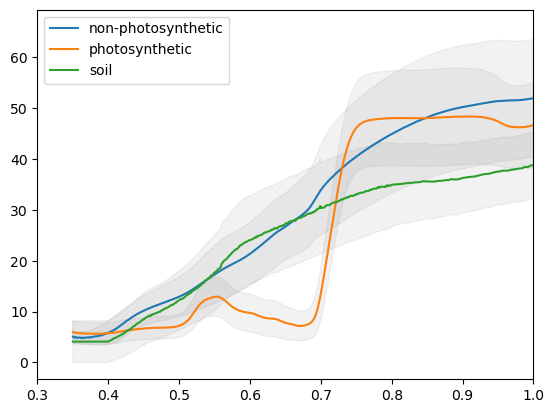

In [25]:
fig, ax = plt.subplots()

for (type, data) in endmember_spectra.groupby("type"):
    # 1 SD
    data = data.reset_index()
    ax.fill_between(
        data["lambda_um"], 
        data["reflectance_mean"]-data["reflectance_std"],
        data["reflectance_mean"]+data["reflectance_std"],
        color="gray",
        alpha=0.1
    )
    ax.plot(data["lambda_um"], data["reflectance_mean"], label=type)

ax.set_xlim(0.3, 1.0)
plt.legend()
plt.show()

Convolve the endmembers with the red/NIR RSR. First, resample the RSR spectra to match the wavelength range of the endmembers.

In [11]:
rsr_red_resample = np.interp(
    endmember_spectra.index.get_level_values("lambda_um").unique(),
    rsr_red["Wavelength"]/1000,
    rsr_red["Band 4"],
    left=0, 
    right=0
)

rsr_nir_resample = np.interp(
    endmember_spectra.index.get_level_values("lambda_um").unique(),
    rsr_nir["Wavelength"]/1000,
    rsr_nir["Band 5"],
    left=0, 
    right=0
)

In [12]:
def ndvi_from_spectrum(reflectance: np.array, rsr_red: np.array, rsr_nir: np.array) -> float:
    red = np.sum(reflectance * rsr_red) / np.sum(rsr_red)
    nir = np.sum(reflectance * rsr_nir) / np.sum(rsr_nir)

    return (nir - red) / (red + nir)

def blend_spectra(endmembers: np.array, f: np.array) -> np.array:
    '''
    Matrix multiplies endmembers (n * lambda) and f (lambda * 1) to create
    a blended spectrum.
    '''
    return (endmembers @ f).T

In [13]:
ndvi_from_spectrum(endmember_spectra.loc["non-photosynthetic"]["reflectance_mean"], rsr_red_resample, rsr_nir_resample)

0.28549927460330776

In [14]:
canopy_endmember = endmember_spectra.loc["photosynthetic", "reflectance_mean"]
nonsyn_endmember = endmember_spectra.loc["non-photosynthetic", "reflectance_mean"]
soil_endmember = endmember_spectra.loc["soil", "reflectance_mean"]

endmember_mtx = np.stack([canopy_endmember, nonsyn_endmember, soil_endmember], axis=-1)
print(endmember_mtx.shape)

(2151, 3)


In [15]:
proportion_space = np.linspace(0, 1, num=50)
f1, f2 = np.meshgrid(proportion_space, proportion_space, indexing="ij")
f3 = 1 - f1 - f2

valid_combos = (f1 >= 0) & (f2 >= 0) & (f3 >= 0) & (np.isclose(f1+f2+f3, 1))

f_grid = np.stack([f1, f2, f3], axis=-1)
f_grid = f_grid[valid_combos, :]
print(f_grid.shape)

(1275, 3)


In [16]:
fspace_ndvi = np.apply_along_axis(lambda f: ndvi_from_spectrum(blend_spectra(endmember_mtx, f[:, np.newaxis]), rsr_red_resample, rsr_nir_resample), 1, f_grid)

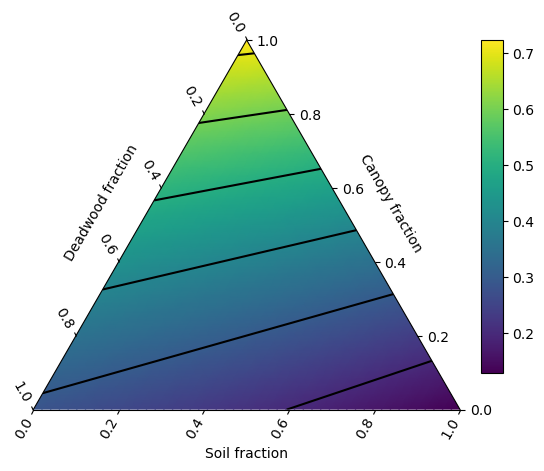

In [32]:
fig, ax = plt.subplots(subplot_kw=dict(projection="ternary"))

contour_levels = np.arange(0.2, 0.71, 0.1)

cs = ax.tripcolor(*f_grid.T, fspace_ndvi, cmap="viridis", shading="gouraud", rasterized=True)
ax.tricontour(*f_grid.T, fspace_ndvi, levels=contour_levels, colors="black")
ax.set_tlabel("Canopy fraction")
ax.set_llabel("Deadwood fraction")
ax.set_rlabel("Soil fraction")
ax.taxis.set_label_position("tick1")
ax.laxis.set_label_position("tick1")
ax.raxis.set_label_position("tick1")


cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
colorbar = fig.colorbar(cs, cax=cax)

plt.show()

In [37]:
canopy_fraction = f_grid[:, 0]
# compute min/max at each value

canopy_f_minmax = pd.DataFrame(dict(canopy_frac=canopy_fraction, ndvi=fspace_ndvi)).groupby("canopy_frac").agg(["min", "max"])

Text(0.5, 1.0, 'OLI RSRs')

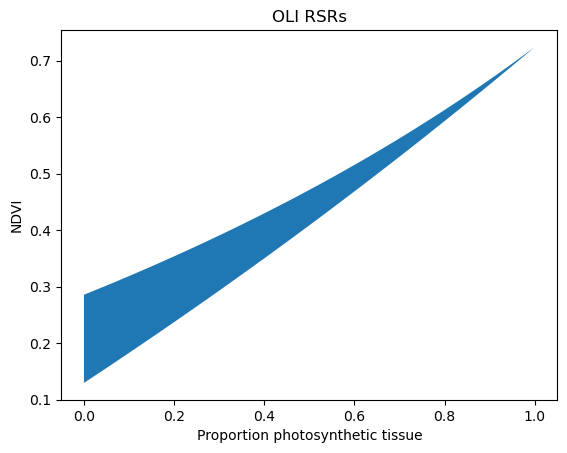

In [43]:
fig, ax = plt.subplots()

ax.fill_between(canopy_f_minmax.index, canopy_f_minmax[("ndvi", "min")], canopy_f_minmax[("ndvi", "max")])
ax.set_xlabel("Proportion photosynthetic tissue")
ax.set_ylabel("NDVI")
ax.set_title("OLI RSRs")